In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Ensure plots render inline inside Jupyter
%matplotlib inline 

from market_data.yf_fred_market_data import MarketDataManager
from market_modelling.path_simulation import HybridValuationVARSimulator
from portfolio_models.linear_models import LongSPYWithTreasuryLadders

initial_nav = 3_000_000
yearly_spending = 450_000
years_to_simulate = 10

random_seed = 42

In [2]:
portfolio_config = {
    "type": "LongSPYWithTreasuryLadders",
    "equity_allocation": 0.8,
    "ladder_allocation": 0.2,
    "yearly_spending":  yearly_spending,
    "dividend_yield": 0.01,
    "average_inflation": 0.034
}

mdm = MarketDataManager(cache_filepath="market_data.parquet")
levels, returns = mdm.get_aligned_data()
simulator = HybridValuationVARSimulator()
simulator.fit(returns, levels)
strategy = LongSPYWithTreasuryLadders.from_json_object(portfolio_config)

spx, yield3m, yield5y = simulator.simulate_paths(years_to_simulate * 252, 1, random_seed)

nav = strategy.run_simulation(
    spx=spx[0, :], 
    yield3m=yield3m[0, :],
    yield5y=yield5y[0, :],
    initial_nav=initial_nav,
    days=252 * years_to_simulate,
    full_book=True)
book = strategy.transaction_book()


output = {
    "spx": spx[0, :],
    "yield3m": yield3m[0, :],
    "yield5y": yield5y[0, :],
    "nav": nav
}
df_path = pd.DataFrame(output)
df_book = pd.DataFrame(book)

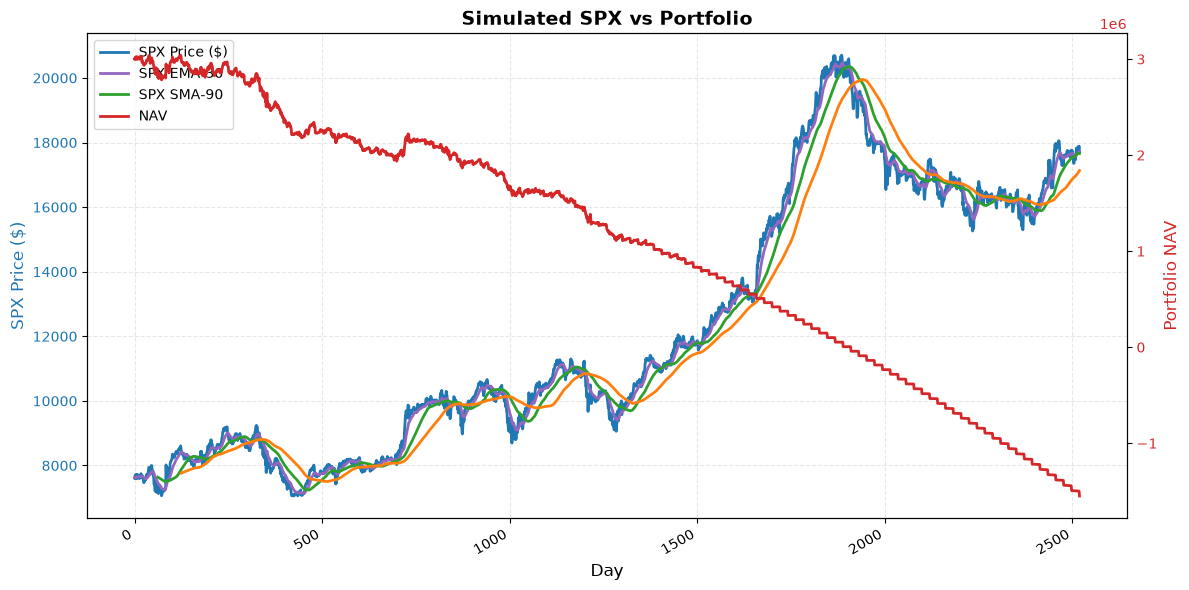

In [3]:
spx_trajectory = df_path["spx"]
spx_df = pd.Series(spx_trajectory)
ema30 = spx_df.ewm(span=20, adjust=False).mean().values
sma90 = spx_df.rolling(window=63).mean()
sma180 = spx_df.rolling(window=126).mean() 

df = pd.DataFrame({
    "Day": range(0, len(spx_trajectory)),
    "SPX": list(spx_trajectory),
    "EMA30": ema30,
    "SMA90": sma90,
    "SMA180": sma180,
    "NAV": df_path["nav"]
})
df.set_index("Day", inplace=True)

# 2. Set up the primary plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot the first time series (Left Y-axis)
color_price = "tab:blue"
ax1.set_xlabel("Day", fontsize=12)
ax1.set_ylabel("SPX Price ($)", color=color_price, fontsize=12)
line1 = ax1.plot(df.index, df["SPX"], color=color_price, linewidth=2, label="SPX Price ($)")
line2 = ax1.plot(df.index, df["EMA30"], color="tab:purple", linewidth=2, label="SPX EMA-30")
line3 = ax1.plot(df.index, df["SMA90"], color="tab:green", linewidth=2, label="SPX SMA-90")
line4 = ax1.plot(df.index, df["SMA180"], color="tab:orange", linewidth=2, label="SPX SMA-180")
ax1.tick_params(axis='y', labelcolor=color_price)
ax1.grid(True, linestyle="--", alpha=0.3)

# 3. Create a twin axis sharing the same X-axis
ax2 = ax1.twinx()  

# Plot the second time series (Right Y-axis)
color_volume = "tab:red"
ax2.set_ylabel("Portfolio NAV", color=color_volume, fontsize=12)
line4 = ax2.plot(df.index, df["NAV"], color=color_volume, linewidth=2, label="NAV")
ax2.tick_params(axis='y', labelcolor=color_volume)

# 4. Combine legends from both axes into a single box
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

# Title and formatting
plt.title("Simulated SPX vs Portfolio", fontsize=14, fontweight="bold")
fig.autofmt_xdate() # Auto-rotate date labels
plt.tight_layout()

plt.show()

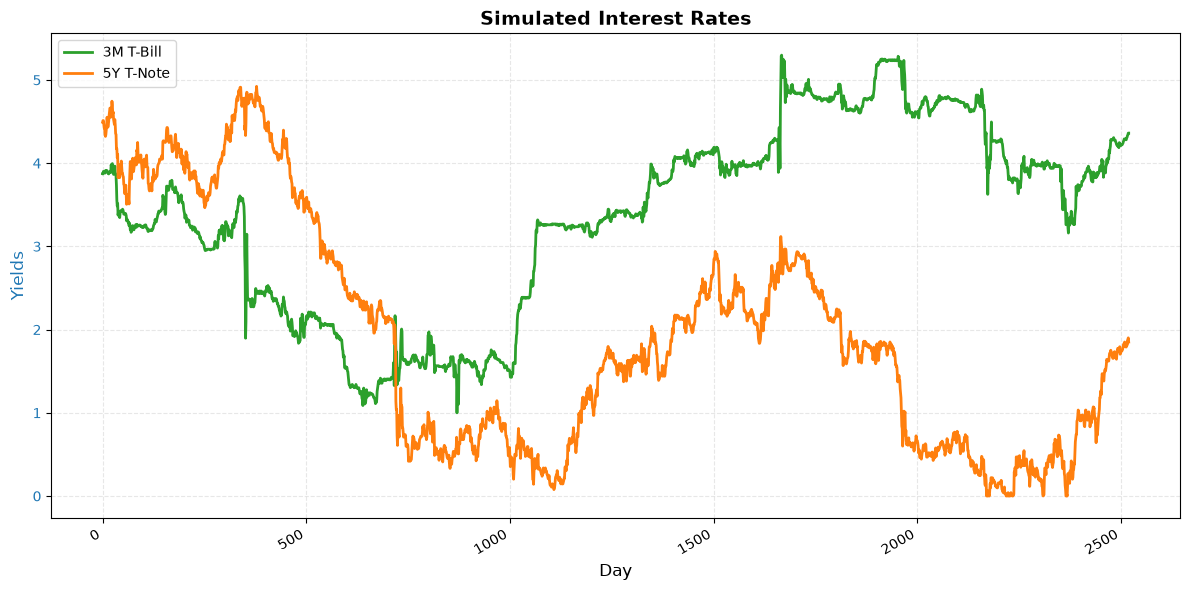

In [4]:
# 2. Set up the primary plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot the first time series (Left Y-axis)
color_price = "tab:blue"
ax1.set_xlabel("Day", fontsize=12)
ax1.set_ylabel("Yields", color=color_price, fontsize=12)
line1 = ax1.plot(df.index, df_path["yield3m"] * 100.0, color="tab:green", linewidth=2, label="3M T-Bill")
line2 = ax1.plot(df.index, df_path["yield5y"] * 100.0, color="tab:orange", linewidth=2, label="5Y T-Note")
ax1.tick_params(axis='y', labelcolor=color_price)
ax1.grid(True, linestyle="--", alpha=0.3)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

# Title and formatting
plt.title("Simulated Interest Rates", fontsize=14, fontweight="bold")
fig.autofmt_xdate() # Auto-rotate date labels
plt.tight_layout()

plt.show()

In [5]:
# Massage the trade book to make it more presentable
df_book["symbol"] = df_book["symbol"].fillna("").astype(str)
df_book["price"] = (df_book["price"] * 100.0).astype(int) / 100.0
df_book["price"] = df_book["price"].astype(str).replace({"0.0": ""})
df_book["total"] = (df_book["total"] * 100.0).fillna(0).astype(int) / 100.0
df_book["total"] = df_book["total"].astype(str).replace({"0.0": ""})
df_book["rate"] = (df_book["rate"] * 10000.0).fillna(0).astype(int) / 100.0
df_book["rate"] = df_book["rate"].astype(str).replace({"0.0": ""})
df_book["maturity"] = df_book["maturity"].fillna(-1).astype("Int64").astype(str).replace({"-1": ""})
df_book["size"] = df_book["size"].fillna(-1).astype(int).astype(str).replace({"-1": ""})

In [6]:
# Tell pandas to show all rows
pd.set_option('display.max_rows', None)
# Tell pandas to show all columns (just in case they are hidden too)
pd.set_option('display.max_columns', None)

df_book

,day,trade,symbol,price,size,total,description,rate,maturity
0,0,buy,SPY,761.6,3152,2400567.43,Initial long equity at 80.0%,,
1,0,buy,T-Note 2 Years,120000.0,,,Initial T-Note ladder setup,4.49,504
2,0,buy,T-Note 3 Years,240000.0,,,Initial T-Note ladder setup,4.49,756
3,0,buy,T-Note 5 Years,120000.0,,,Initial T-Note ladder setup,4.49,1260
4,0,buy,,119432.56,,,Cash equivalents in short term t-bills,3.87,
5,0,sell,,761.6,962,,Selling shares to cover a year of runway,,
6,0,mtm,Cash,852111.4,,,Cash MTM,,
7,0,mtm,SPY,761.6,2190,1667906.94,SPY MTM,,
8,0,mtm,T-Note,120000.0,,,T-Note MTM,4.49,504
9,0,mtm,T-Note,240000.0,,,T-Note MTM,4.49,756
